# **READ ME FILE**

This code compresses a simple parrot image using a from scratch implementation of k-means clustering.

Required libraries:
* numpy as np
* matplotlib.pyplot as plt
* cv2

**IMPORTANT NOTE**
To run this code in your environment you must allow Google Colab to mount to your drive. Before running the code you must change your base directory to the location of the data files in the section labelled "CHANGE BASE DIRECTORY HERE TO YOUR GDRIVE FILE LOCATION" in the first code blocl.



**Mounting Google Drive + Importing Libraries**

In [ ]:
## mounting Google Drive for file import ##
####### you must allow google to mount to your drive ##########
from google.colab import drive
drive.mount('/content/drive')

######## CHANGE TO BASE DIRECTORY HERE TO YOUR GDRIVE FILE LOCATION ########
%cd /content/drive/MyDrive/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/


In [ ]:
## importing libraries
import matplotlib.pyplot as plt
import cv2

**Scratch implementation of k means clustering algorithm:**

This algorithm takes a 2D image vector, the number of clusters (k) and the maximum iterations to produce a compressed image.

In [ ]:

def kmeans_algo(image_vector, k, max_iter):
  ## copy the image
  image_vector = image_vector.copy()
  height_new, width_new = np.shape(image_vector)

  np.random.seed(23) ## set seed
  k = k
  max_iter = max_iter

  ## initialization: pick k random centroid points
  centroid_list = []
  for i in range(k):
    centroid_list.append(image_vector[np.random.choice(image_vector.shape[0], 1, replace=False)][0])


  for i in range(max_iter):
    labels = []
    store_values = []
    for i in range(k):
      store_values.append([])

    ## for all pixels, calculate the distance
    for i in range(height_new):
      min_distance = float('inf')
      which_centroid = -1

      ## calculate distances from all centroids, find the min dist centroid
      for j in range(k):
        distance = np.linalg.norm(image_vector[i,:] - centroid_list[j])

        ## iterate through centroids, find the one with the min distance
        if distance < min_distance:
          min_distance = distance
          which_centroid = j


      ## store location of the pixel and the pixel to the centroid list
      labels.append(which_centroid)
      store_values[which_centroid].append(image_vector[i, :])


    ## calculate the means of each centroid list for update and next iter.
    for i in range(k):
      centroid_list[i] = np.mean(store_values[i], axis=0)


    ## reassign the mean of each centroid to the pixel
    for i in range(height_new):
      ## find which centroid
      which_mean = labels[i]

      ## assign that mean to the pixel
      image_vector[i] = centroid_list[which_mean]


  return image_vector





original image shape: (128, 128, 3)
transformed image shape: (16384, 3)


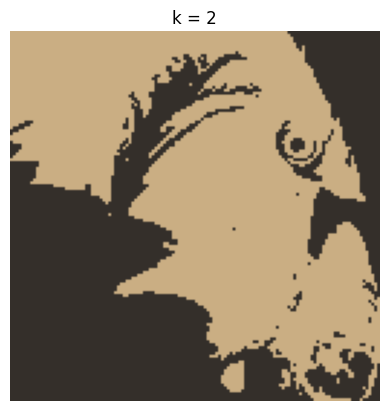

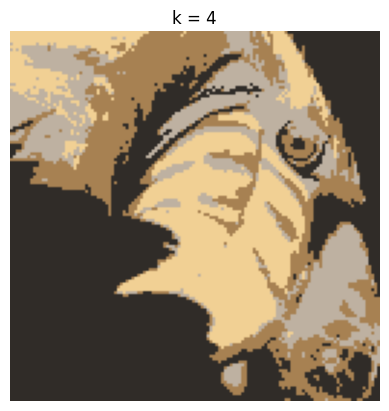

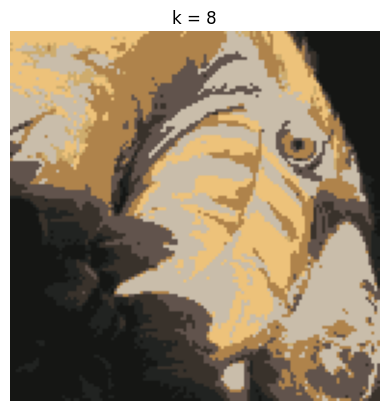

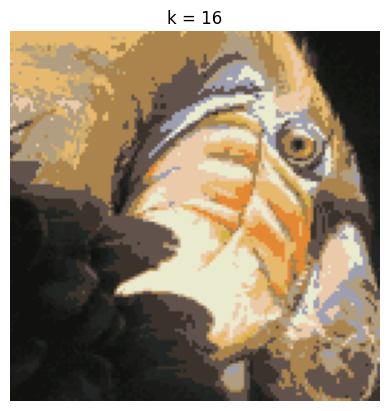

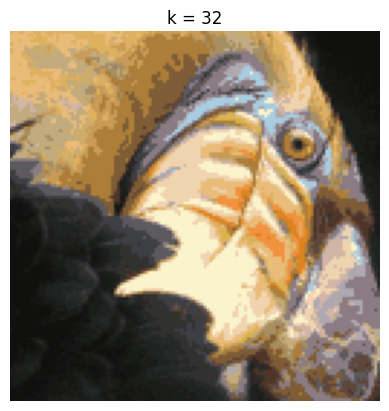

In [ ]:
## Bringing in the test image
import cv2
img = cv2.imread('test_image.png')
print(f"original image shape: {img.shape}")
height, width, channels = np.shape(img)

## create storage list
pixel_holder = []

for j in range(height):
  for i in range(width):
    pixel = img[j][i]
    pixel_holder.append(img[j][i]) # Read the pixel at location (i,j) and store

## convert to array
image_vector = np.array(pixel_holder, dtype=float) ## AI USAGE for dtype
print(f"transformed image shape: {image_vector.shape}")



## applying the k means cluster algo across different ranges of k

k_range = [2, 4, 8, 16, 32]

for num_k in k_range:
  image_vector_2 = image_vector.copy()
  k = num_k
  max_iter = 30

  # AI Usage from here down!
  img_vector_compressed = kmeans_algo(image_vector_2, k, max_iter)
  img_vector_compressed = img_vector_compressed.reshape(height, width, 3).astype(np.uint8)

  # Show with matplotlib
  plt.imshow(cv2.cvtColor(img_vector_compressed.astype(np.uint8), cv2.COLOR_BGR2RGB))
  plt.axis('off')
  plt.title(f"k = {k}")
  plt.show()




**Discussion:**

I started by self implementing the K-means clustering algorithm to see the impact of compressing the simple parrot image into clusters. As seen above, an extremely low k value such as k=2 is barely distinguishable as a parrot if you didn't see the reference image before processing. k=4 and k=8 improved the image quality, but the image began to improve drastically at k=16. I found the best balance at k=32, where the image is very recognizable with sufficient coloring but still had a reasonable run time. At k=64, the run time for the algorithm was very slow and it was more computationally heavy on memory, and the image didn't show significant improvement compared to k=32 so it was deleted from the notebook.

